# NeuroBridge-S4 Graph Learning — Phase 11: Operational Resilience Interpretation Layer

*Adaptive resilience state interpretation from within-subject longitudinal graph trajectories.*

## 2. Plain-language purpose

Phase 11 translates within-subject graph trajectories (Phase 6), trajectory attribution (Phase 7), reference-calibrated envelope results (Phase 8), recovery/persistence patterns, HRP hazard-context alignment, and data coverage from the HRP-like adapter layer (Phase 10) into an **operational resilience interpretation layer**.

It does **not** prescribe monitoring, treatment, or risk action. It creates an evidence-chain interpretation for expert review.

## 3. Why this is stronger than monitoring priority

A simple monitoring-priority label only says *what to look at next*. Operational resilience interpretation asks *what adaptive pattern is visible in the longitudinal graph trajectory*: stable compensation, localized shift, distributed adaptive load, systemic strain pattern, persistent displacement, recovery lag, multi-domain instability, or coverage-limited interpretation.

## 4. Scientific guardrails

- This is **not** actual Artemis II data unless explicitly provided.
- If example/schema-demonstration data are used, they are **not** scientific evidence.
- This is **not** diagnosis.
- This is **not** treatment guidance.
- This is **not** health risk scoring.
- This is **not** exposure measurement.
- This is **not** mission readiness classification.
- This is **not** an operational medical decision.
- This **is** a research-review interpretation layer for expert evaluation.

> Operational resilience interpretation is a research-review layer. It describes baseline-relative adaptation patterns for expert interpretation. It is not diagnosis, treatment guidance, health risk scoring, exposure measurement, or an operational medical decision.

In [1]:
import sys
from pathlib import Path

REPO = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SRC = REPO / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import pandas as pd
from IPython.display import display

from neurobridge_graph.resilience_interpretation import (
    load_phase11_inputs, build_phase11_input_readiness_report,
    core_inputs_available, build_resilience_state_table,
    build_mission_relevance_translation, interpret_subject_timepoint_resilience,
    get_subject_timepoint_pairs,
)
from neurobridge_graph.resilience_rules import RESILIENCE_STATES
from neurobridge_graph.resilience_reporting import (
    generate_resilience_card, generate_phase11_report,
)
from neurobridge_graph.resilience_visualization import (
    plot_resilience_state_summary, plot_resilience_state_timeline,
    plot_adaptation_mode_heatmap, plot_evidence_chain_summary,
)

TABLES_DIR = REPO / 'results' / 'tables'
FIG_DIR = REPO / 'results' / 'figures'
REPORT_DIR = REPO / 'results' / 'reports'
CARD_DIR = REPORT_DIR / 'resilience_cards'
for d in (TABLES_DIR, FIG_DIR, REPORT_DIR, CARD_DIR):
    d.mkdir(parents=True, exist_ok=True)
print('Repository:', REPO)

Repository: /Users/rm/Desktop/NeuroBridge-S4-Graph-Learning


## 5. Load Phase 6-10 inputs

Load every available Phase 6-10 table. Missing optional tables do not fail; missing required core tables (Phase 6-8) stop interpretation.

In [2]:
tables = load_phase11_inputs(TABLES_DIR)
readiness = build_phase11_input_readiness_report(tables, TABLES_DIR)
readiness.to_csv(TABLES_DIR / 'phase11_input_readiness_check.csv', index=False)
display(readiness)

CORE_OK = core_inputs_available(tables)
if not CORE_OK:
    print('\nPhase 11 requires Phase 6-8 outputs. Please run the '
          'longitudinal trajectory, attribution, and reference-envelope '
          'notebooks first.')
else:
    print('\nCore Phase 6-8 inputs available; proceeding with interpretation.')

,table_name,required_or_optional,status,rows,columns,notes
0,longitudinal_node_deltas,optional,available,60,12,loaded
1,longitudinal_graph_deltas,optional,available,70,10,loaded
2,longitudinal_hazard_deltas,optional,available,50,10,loaded
3,recovery_metrics,optional,available,8,11,loaded
4,trajectory_node_attribution,required,available,60,12,loaded
5,trajectory_graph_metric_attribution,optional,available,70,12,loaded
6,trajectory_subgraph_attribution,required,available,50,11,loaded
7,trajectory_hazard_attribution,optional,available,50,12,loaded
8,recovery_attribution,optional,available,8,10,loaded
9,phase7_attribution_summary,optional,available,10,10,loaded



Core Phase 6-8 inputs available; proceeding with interpretation.


## 6. Adaptive resilience states

Eight transparent, rule-based interpretation states. These are research-review interpretations, not validated operational states, clinical labels, mission-readiness categories, or health-risk levels.

In [3]:
state_defs = {
    'Stable compensated trajectory': 'Low baseline-relative deltas; few/no outside-envelope features; recovery near baseline.',
    'Localized adaptive shift': 'One dominant domain/subgraph contributor with limited spread.',
    'Distributed adaptive load': 'Multiple active domains and subgraphs; broad graph displacement.',
    'Systemic strain pattern': 'High displacement across multiple features/subgraphs; recovery not established.',
    'Persistent displacement': 'Graph remains displaced into the post-shift phase.',
    'Recovery lag pattern': 'Partial or delayed return toward baseline.',
    'Multi-domain instability': 'Mixed-direction deltas; alternating subgraph dominance.',
    'Coverage-limited interpretation': 'Interpretation limited by insufficient data coverage.',
}
display(pd.DataFrame({'state': list(state_defs), 'definition': list(state_defs.values())}))

,state,definition
0,Stable compensated trajectory,Low baseline-relative deltas; few/no outside-e...
1,Localized adaptive shift,One dominant domain/subgraph contributor with ...
2,Distributed adaptive load,Multiple active domains and subgraphs; broad g...
3,Systemic strain pattern,High displacement across multiple features/sub...
4,Persistent displacement,Graph remains displaced into the post-shift ph...
5,Recovery lag pattern,Partial or delayed return toward baseline.
6,Multi-domain instability,Mixed-direction deltas; alternating subgraph d...
7,Coverage-limited interpretation,Interpretation limited by insufficient data co...


## 7. Build evidence chains

For each subject/timepoint, collect the top domain contributor, top graph metric, top subgraph, top hazard-context alignment, outside-envelope status, recovery/persistence evidence, and data gaps.

In [4]:
evidence_rows = []
if CORE_OK:
    pairs = get_subject_timepoint_pairs(tables)
    for _, p in pairs.iterrows():
        interp = interpret_subject_timepoint_resilience(p['subject_id'], p['timepoint'], tables)
        for i, bullet in enumerate(interp['evidence_chain'], start=1):
            evidence_rows.append({
                'subject_id': interp['subject_id'], 'timepoint': interp['timepoint'],
                'mission_phase': interp['mission_phase'],
                'resilience_state_label': interp['resilience_state_label'],
                'evidence_order': i, 'evidence': bullet,
            })
evidence_chains = pd.DataFrame(evidence_rows, columns=[
    'subject_id', 'timepoint', 'mission_phase', 'resilience_state_label',
    'evidence_order', 'evidence'])
evidence_chains.to_csv(TABLES_DIR / 'resilience_evidence_chains.csv', index=False)
display(evidence_chains.head(12))

,subject_id,timepoint,mission_phase,resilience_state_label,evidence_order,evidence
0,Demo_Crew_01,T0_baseline,baseline,Stable compensated trajectory,1,Top baseline-relative domain contributor: Body...
1,Demo_Crew_01,T0_baseline,baseline,Stable compensated trajectory,2,Leading graph-metric displacement: mean_node_a...
2,Demo_Crew_01,T0_baseline,baseline,Stable compensated trajectory,3,Dominant biological subgraph: cardiometabolic ...
3,Demo_Crew_01,T0_baseline,baseline,Stable compensated trajectory,4,Reference-calibrated envelope: 0 feature(s) ou...
4,Demo_Crew_01,T0_baseline,baseline,Stable compensated trajectory,5,HRP hazard-context alignment: space radiation ...
5,Demo_Crew_01,T0_baseline,baseline,Stable compensated trajectory,6,Recovery / persistence: categories observed = ...
6,Demo_Crew_01,T0_baseline,baseline,Stable compensated trajectory,7,Data coverage: 11/12 biological domains covered.
7,Demo_Crew_01,T1_pre,pre_mission,Localized adaptive shift,1,Top baseline-relative domain contributor: Card...
8,Demo_Crew_01,T1_pre,pre_mission,Localized adaptive shift,2,Leading graph-metric displacement: total_node_...
9,Demo_Crew_01,T1_pre,pre_mission,Localized adaptive shift,3,Dominant biological subgraph: cardiometabolic ...


## 8. Classify adaptive resilience states

One row per subject/timepoint with state, dominant adaptation mode, confidence, and a short evidence chain.

In [5]:
resilience_df = build_resilience_state_table(tables)
resilience_df.to_csv(TABLES_DIR / 'resilience_state_table.csv', index=False)
display(resilience_df[['subject_id', 'timepoint', 'mission_phase',
    'resilience_state_label', 'dominant_adaptation_mode', 'confidence_level',
    'evidence_chain_short', 'interpretation']])

,subject_id,timepoint,mission_phase,resilience_state_label,dominant_adaptation_mode,confidence_level,evidence_chain_short,interpretation
0,Demo_Crew_01,T0_baseline,baseline,Stable compensated trajectory,Cardiometabolic-recovery dominant,high,Top baseline-relative domain contributor: Body...,Stable compensated trajectory: The graph remai...
1,Demo_Crew_01,T1_pre,pre_mission,Localized adaptive shift,Multi-subgraph distributed,high,Top baseline-relative domain contributor: Card...,Localized adaptive shift: A localized biologic...
2,Demo_Crew_01,T2_inflight,inflight,Systemic strain pattern,Multi-subgraph distributed,high,Top baseline-relative domain contributor: Body...,Systemic strain pattern: The graph trajectory ...
3,Demo_Crew_01,T3_post,postflight,Systemic strain pattern,Multi-subgraph distributed,high,Top baseline-relative domain contributor: Body...,Systemic strain pattern: The graph trajectory ...
4,Demo_Crew_01,T4_recovery,recovery,Persistent displacement,Multi-subgraph distributed,high,Top baseline-relative domain contributor: Infl...,Persistent displacement: The graph remains shi...
5,Demo_Crew_02,T0_baseline,baseline,Stable compensated trajectory,Cardiometabolic-recovery dominant,high,Top baseline-relative domain contributor: Body...,Stable compensated trajectory: The graph remai...
6,Demo_Crew_02,T1_pre,pre_mission,Localized adaptive shift,Multi-subgraph distributed,high,Top baseline-relative domain contributor: Meta...,Localized adaptive shift: A localized biologic...
7,Demo_Crew_02,T2_inflight,inflight,Systemic strain pattern,Multi-subgraph distributed,high,Top baseline-relative domain contributor: Meta...,Systemic strain pattern: The graph trajectory ...
8,Demo_Crew_02,T3_post,postflight,Systemic strain pattern,Multi-subgraph distributed,high,Top baseline-relative domain contributor: Meta...,Systemic strain pattern: The graph trajectory ...
9,Demo_Crew_02,T4_recovery,recovery,Localized adaptive shift,Multi-subgraph distributed,high,Top baseline-relative domain contributor: Meta...,Localized adaptive shift: A localized biologic...


## 9. Mission relevance translation

Expert review context only — **not** operational instruction, risk classification, treatment recommendation, or readiness decision.

In [6]:
mission_relevance = build_mission_relevance_translation(resilience_df, tables)
mission_relevance.to_csv(TABLES_DIR / 'mission_relevance_translation.csv', index=False)
display(mission_relevance[['subject_id', 'timepoint', 'resilience_state_label',
    'mission_relevance_context', 'expert_review_context',
    'data_streams_that_would_strengthen_interpretation']])

,subject_id,timepoint,resilience_state_label,mission_relevance_context,expert_review_context,data_streams_that_would_strengthen_interpretation
0,Demo_Crew_01,T0_baseline,Stable compensated trajectory,Trajectory tracks personal baseline; useful as...,Suitable as a within-subject reference; no spe...,body composition / physical status
1,Demo_Crew_01,T1_pre,Localized adaptive shift,A localized adaptive shift is visible; expert ...,Expert review may inspect the dominant domain/...,body composition / physical status
2,Demo_Crew_01,T2_inflight,Systemic strain pattern,A stronger multi-system strain-like pattern is...,Flagged for expert review of the multi-system ...,body composition / physical status
3,Demo_Crew_01,T3_post,Systemic strain pattern,A stronger multi-system strain-like pattern is...,Flagged for expert review of the multi-system ...,body composition / physical status
4,Demo_Crew_01,T4_recovery,Persistent displacement,The graph remains displaced from baseline into...,Expert review may consider whether follow-up t...,body composition / physical status
5,Demo_Crew_02,T0_baseline,Stable compensated trajectory,Trajectory tracks personal baseline; useful as...,Suitable as a within-subject reference; no spe...,body composition / physical status
6,Demo_Crew_02,T1_pre,Localized adaptive shift,A localized adaptive shift is visible; expert ...,Expert review may inspect the dominant domain/...,body composition / physical status
7,Demo_Crew_02,T2_inflight,Systemic strain pattern,A stronger multi-system strain-like pattern is...,Flagged for expert review of the multi-system ...,body composition / physical status
8,Demo_Crew_02,T3_post,Systemic strain pattern,A stronger multi-system strain-like pattern is...,Flagged for expert review of the multi-system ...,body composition / physical status
9,Demo_Crew_02,T4_recovery,Localized adaptive shift,A localized adaptive shift is visible; expert ...,Expert review may inspect the dominant domain/...,body composition / physical status


## 10. Generate resilience cards

One Adaptive Resilience Interpretation Card per subject/timepoint, saved as text under `results/reports/resilience_cards/`.

In [7]:
card_paths = []
if CORE_OK:
    pairs = get_subject_timepoint_pairs(tables)
    for _, p in pairs.iterrows():
        interp = interpret_subject_timepoint_resilience(p['subject_id'], p['timepoint'], tables)
        card = generate_resilience_card(interp)
        fname = f"subject_{interp['subject_id']}__timepoint_{interp['timepoint']}.txt"
        (CARD_DIR / fname).write_text(card)
        card_paths.append(CARD_DIR / fname)
print(f'Generated {len(card_paths)} resilience cards.')
if card_paths:
    print('\n' + card_paths[0].read_text())

Generated 10 resilience cards.

Adaptive Resilience Interpretation Card

Subject: Demo_Crew_01
Timepoint: T0_baseline
Mission phase: baseline

Adaptive resilience state: Stable compensated trajectory (confidence: high)
Dominant adaptation mode: Cardiometabolic-recovery dominant
Primary graph displacement pattern: localized to the cardiometabolic subgraph

Evidence chain:
1. Top baseline-relative domain contributor: Body composition / physical status (contribution share 0.00).
2. Leading graph-metric displacement: mean_node_activation (share 0.00).
3. Dominant biological subgraph: cardiometabolic (share 0.00); 0 subgraph(s) involved.
4. Reference-calibrated envelope: 0 feature(s) outside the expected envelope (node 0, graph 0, hazard 0); overall flag 'within_expected_envelope'.
5. HRP hazard-context alignment: space radiation (share 0.00); alignment context only, not exposure measurement.
6. Recovery / persistence: categories observed = [returned_near_baseline]; minimum recovery fractio

## 11. Visualize resilience interpretation

Figures degrade gracefully when no interpretations are available. Each figure carries the research-review caption.

In [8]:
f1 = plot_resilience_state_summary(resilience_df, FIG_DIR / 'phase11_resilience_state_summary.png')
f2 = plot_resilience_state_timeline(resilience_df, FIG_DIR / 'phase11_resilience_state_timeline.png')
f3 = plot_adaptation_mode_heatmap(resilience_df, FIG_DIR / 'phase11_adaptation_mode_heatmap.png')
f4 = plot_evidence_chain_summary(resilience_df, FIG_DIR / 'phase11_evidence_chain_summary.png')
for f in (f1, f2, f3, f4):
    print('saved', f)

saved /Users/rm/Desktop/NeuroBridge-S4-Graph-Learning/results/figures/phase11_resilience_state_summary.png
saved /Users/rm/Desktop/NeuroBridge-S4-Graph-Learning/results/figures/phase11_resilience_state_timeline.png
saved /Users/rm/Desktop/NeuroBridge-S4-Graph-Learning/results/figures/phase11_adaptation_mode_heatmap.png
saved /Users/rm/Desktop/NeuroBridge-S4-Graph-Learning/results/figures/phase11_evidence_chain_summary.png


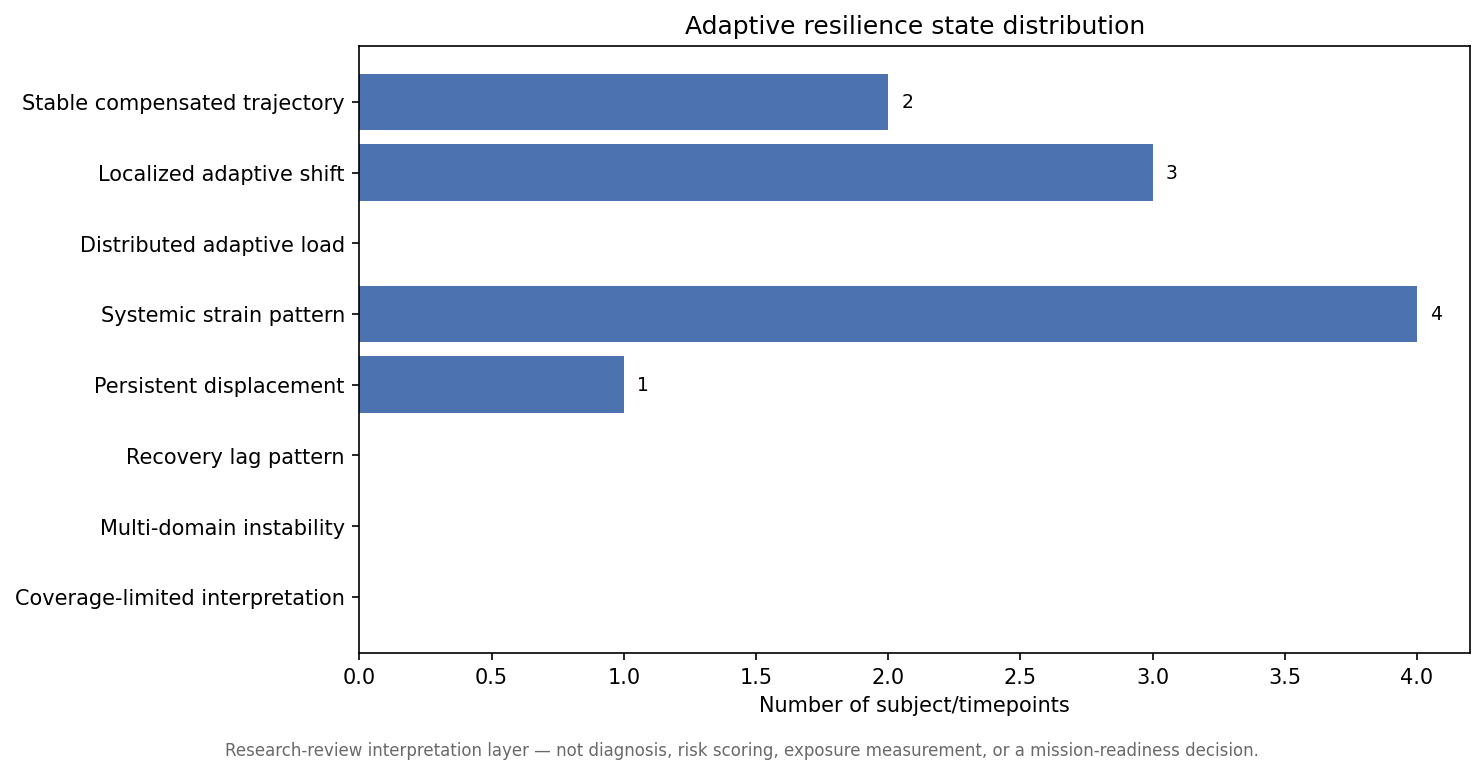

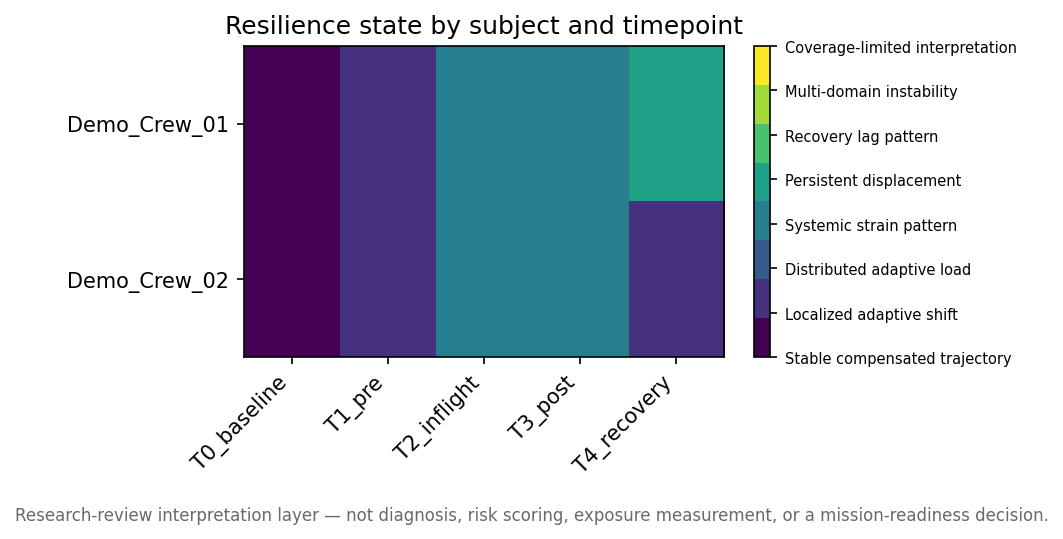

In [9]:
from IPython.display import Image
display(Image(filename=str(FIG_DIR / 'phase11_resilience_state_summary.png')))
display(Image(filename=str(FIG_DIR / 'phase11_resilience_state_timeline.png')))

## 12. Generate Phase 11 report

Plain-language report: overview, input readiness, state definitions, number of subject/timepoints interpreted, state distribution, dominant adaptation modes, example evidence chains, data gaps, limitations, guardrails, and the next-phase recommendation.

In [10]:
provenance = ('Demonstration/longitudinal proxy data unless real HRP data '
              'were explicitly provided; not scientific evidence.')
report = generate_phase11_report(resilience_df, mission_relevance, readiness, provenance)
report_path = REPORT_DIR / 'phase11_operational_resilience_interpretation_report.txt'
report_path.write_text(report)
print(report)

NeuroBridge-S4 Graph Learning
Phase 11 — Operational Resilience Interpretation Report

Overview
----------------------------------------------------------------------
This report translates within-subject longitudinal graph trajectories, attribution, reference-calibrated envelope status, recovery/persistence information, HRP hazard-context alignment, and adapter-layer data coverage into adaptive resilience state interpretations for expert review.

Data provenance: Demonstration/longitudinal proxy data unless real HRP data were explicitly provided; not scientific evidence.

Input readiness
----------------------------------------------------------------------
- longitudinal_node_deltas [optional]: available (60 rows)
- longitudinal_graph_deltas [optional]: available (70 rows)
- longitudinal_hazard_deltas [optional]: available (50 rows)
- recovery_metrics [optional]: available (8 rows)
- trajectory_node_attribution [required]: available (60 rows)
- trajectory_graph_metric_attribution [op

## 13. Conclusion

Phase 11 moves the project from measurement and attribution toward systems-level interpretation. It creates a structured evidence chain from graph trajectory to adaptive resilience state without making clinical, causal, exposure, risk, or mission-readiness claims.

**Next phase:** Phase 12 — Self-supervised within-subject temporal graph learning.